In [1]:
options(repos = c(CRAN = "https://cloud.r-project.org"))

if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate)
library(readr)
library(magrittr)
library(stringr)
library(tidyr)

Loading required package: pacman


Attaching package: ‘magrittr’


The following object is masked from ‘package:purrr’:

    set_names


The following object is masked from ‘package:tidyr’:

    extract




In [2]:
# Load data for a specific year
data_2011 <- read_csv('../data/output/data-2011.csv')
data_2012 <- read_csv('../data/output/data-2012.csv')
data_2013 <- read_csv('../data/output/data-2013.csv')
data_2014 <- read_csv('../data/output/data-2014.csv')
data_2015 <- read_csv('../data/output/data-2015.csv')
data_2016 <- read_csv('../data/output/data-2016.csv')
data_2017 <- read_csv('../data/output/data-2017.csv')
data_2018 <- read_csv('../data/output/data-2018.csv')
data_2019 <- read_csv('../data/output/data-2019.csv')

# Combine all datasets into one
final_hcris_data <- bind_rows(data_2011, data_2012, data_2013, data_2014, 
                               data_2015, data_2016, data_2017, data_2018, 
                               data_2019)


Rows: 45 Columns: 48
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (8): provider_number, street, city, state, zip, county, source, .groups
dbl  (20): year, beds, tot_charges, tot_discounts, tot_operating_exp, ip_cha...
lgl  (16): data_source, net_pat_rev, name, new_cap_ass, cash, fixed_assets, ...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 90 Columns: 48
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (8): provider_number, street, city, state, zip, county, source, .groups
dbl  (20): year, beds, tot_charges, tot_discounts, tot_operating_exp, ip_cha...
lgl  (16): data_source, net_pat_rev, name, new_cap_ass, cash, fixed_assets, ...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to 

In [3]:
print(final_hcris_data)
# Replace -Inf with NA or 0
final_hcris_data$beds[final_hcris_data$beds == -Inf] <- NA  # or 0



# A tibble: 827 × 48
   provider_number  year  beds tot_charges tot_discounts tot_operating_exp
   <chr>           <dbl> <dbl>       <dbl>         <dbl>             <dbl>
 1 010054           2011   109  240108319.    203712711.         41313441.
 2 040118           2011   100  322063465     223646486          85967140 
 3 050091           2011    81  218953277     184640807          36425684 
 4 050192           2011    49   59928165.     41818650.         25245891.
 5 050325           2011  -Inf          0             0                 0 
 6 050468           2011   103  397035793.    288800030.        110695854.
 7 084003           2011    58   34258997      19523525          14027262 
 8 100014           2011   112  193652630.      6503461.         73933007.
 9 102016           2011    29   47505873      39113434           8918451 
10 103038           2011    60   26532049       7166252          15869823 
# ℹ 817 more rows
# ℹ 42 more variables: ip_charges <dbl>, icu_charges <dbl>,
#

In [4]:
df_loaded <- read.table("/home/salizad/econ470/a0/work/hwk5/medicaid_data.txt", 
                         sep = "\t", 
                         header = TRUE, 
                         fill = TRUE,  # This will fill missing values in rows
                         quote = "")

In [5]:
# Merge the datasets using state as the key
combined_data <- final_hcris_data %>%
    left_join(df_loaded, by = "state")  # Adjust the column name if necessary

# Q1. 
Provide a table of mean hospital uncompensated care (in millions of dollars) by year, from 2010 through 2018. How has uncompensated care changed over time?



In [6]:
# Create a new column for uncompensated care in millions
combined_data <- combined_data %>%
    mutate(uncomp_care_millions = uncomp_care / 1e6)  # Convert to millions

# Calculate mean uncompensated care by year
mean_uncomp_care <- combined_data %>%
    group_by(year) %>%
    summarize(mean_uncomp_care = mean(uncomp_care_millions, na.rm = TRUE))

# Print the resulting table
print(mean_uncomp_care)

# A tibble: 9 × 2
   year mean_uncomp_care
  <dbl>            <dbl>
1  2011             2.35
2  2012             8.44
3  2013             9.41
4  2014            11.7 
5  2015             8.15
6  2016             6.47
7  2017             5.15
8  2018            13.8 
9  2019            14.3 


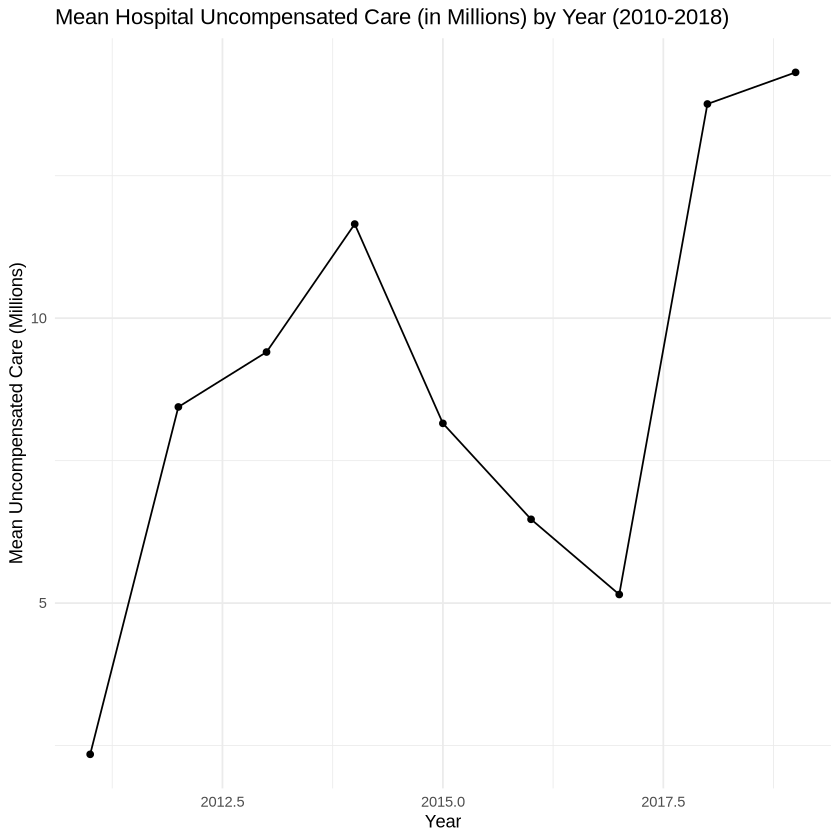

In [7]:
# Plot mean uncompensated care over the years
ggplot(mean_uncomp_care, aes(x = year, y = mean_uncomp_care)) +
    geom_line() +
    geom_point() +
    labs(title = "Mean Hospital Uncompensated Care (in Millions) by Year (2010-2018)",
         x = "Year",
         y = "Mean Uncompensated Care (Millions)") +
    theme_minimal()

Uncompensated care has shown considerable fluctuation over the years. Starting at 2.35 million in 2011, it increased significantly to 9.41 million by 2013, reflecting rising healthcare needs. After the implementation of Medicaid expansion in 2014, it peaked at 11.7 million, indicating a jump in uncompensated care, likely due to more individuals seeking healthcare services. Subsequently, it experienced a decline, dropping to 5.15 million by 2017. However, in the following years, there was another rise, reaching 14.3 million by 2019. This pattern suggests that while expansion initially increased uncompensated care, subsequent years saw variability, possibly influenced by changes in policy, healthcare access, or economic conditions.

# Q2.
Plot mean uncompensated care over time separately for states that expanded Medicaid in 2014 versus states that never expanded. Drop all states that expanded after 2014. Does the graph suggest a potential treatment effect?

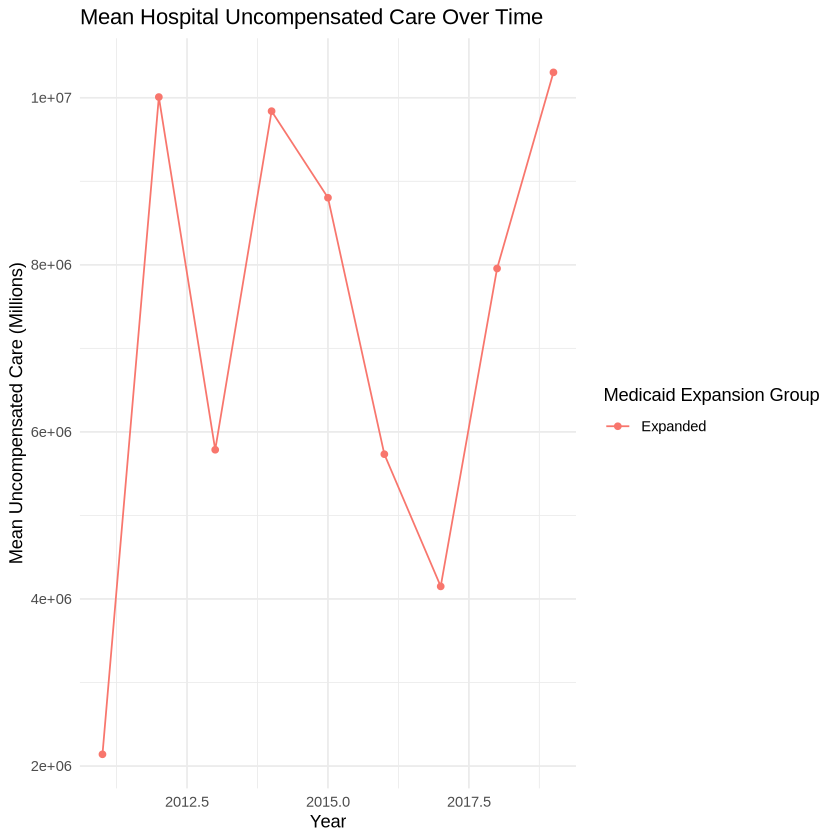

In [8]:
# Define state abbreviations
state_abbreviations <- c(
    "Alabama" = "AL", "Alaska" = "AK", "Arizona" = "AZ", "Arkansas" = "AR",
    "California" = "CA", "Colorado" = "CO", "Connecticut" = "CT", "Delaware" = "DE",
    "Florida" = "FL", "Georgia" = "GA", "Hawaii" = "HI", "Idaho" = "ID",
    "Illinois" = "IL", "Indiana" = "IN", "Iowa" = "IA", "Kansas" = "KS",
    "Kentucky" = "KY", "Louisiana" = "LA", "Maine" = "ME", "Maryland" = "MD",
    "Massachusetts" = "MA", "Michigan" = "MI", "Minnesota" = "MN", "Mississippi" = "MS",
    "Missouri" = "MO", "Montana" = "MT", "Nebraska" = "NE", "Nevada" = "NV",
    "New Hampshire" = "NH", "New Jersey" = "NJ", "New Mexico" = "NM", "New York" = "NY",
    "North Carolina" = "NC", "North Dakota" = "ND", "Ohio" = "OH", "Oklahoma" = "OK",
    "Oregon" = "OR", "Pennsylvania" = "PA", "Rhode Island" = "RI", "South Carolina" = "SC",
    "South Dakota" = "SD", "Tennessee" = "TN", "Texas" = "TX", "Utah" = "UT",
    "Vermont" = "VT", "Virginia" = "VA", "Washington" = "WA", "West Virginia" = "WV",
    "Wisconsin" = "WI", "Wyoming" = "WY"
)
 
# Prepare data
df_loaded <- df_loaded %>%
    mutate(state_abbr = state_abbreviations[state])
 
# Filter states that expanded in 2014 and those that never expanded
medicaid_states <- df_loaded %>%
    filter(expanded == TRUE | expanded == FALSE) %>%
    filter(!(state %in% df_loaded$state[df_loaded$expanded == TRUE & df_loaded$year > 2014])) %>%
    select(state_abbr) %>%
    distinct()
 
# Filter combined data
filtered_data <- combined_data %>%
    filter(state %in% medicaid_states$state_abbr)
 
# Summarize and plot
if(nrow(filtered_data) > 0) {
    mean_uncomp_care <- filtered_data %>%
        group_by(year, state) %>%
        summarize(mean_uncomp_care = mean(uncomp_care, na.rm = TRUE), .groups = 'drop') %>%
        mutate(expansion_group = ifelse(state %in% df_loaded$state_abbr[df_loaded$expanded == TRUE], "Expanded", "Never Expanded")) %>%
        group_by(year, expansion_group) %>%
        summarize(mean_uncomp_care = mean(mean_uncomp_care, na.rm = TRUE), .groups = 'drop')
 
    ggplot(mean_uncomp_care, aes(x = year, y = mean_uncomp_care, color = expansion_group)) +
        geom_line() +
        geom_point() +
        labs(title = "Mean Hospital Uncompensated Care Over Time",
             x = "Year",
             y = "Mean Uncompensated Care (Millions)",
             color = "Medicaid Expansion Group") +
        theme_minimal()
} else {
    print("No data available for plotting.")
}

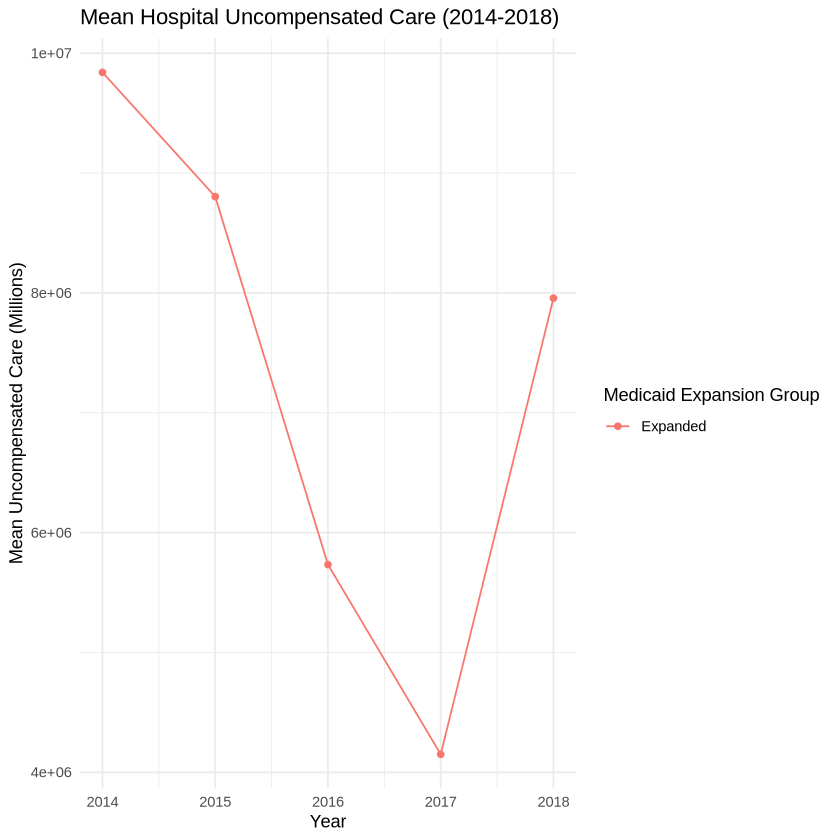

In [9]:
# Define state abbreviations
state_abbreviations <- c(
    "Alabama" = "AL", "Alaska" = "AK", "Arizona" = "AZ", "Arkansas" = "AR",
    "California" = "CA", "Colorado" = "CO", "Connecticut" = "CT", "Delaware" = "DE",
    "Florida" = "FL", "Georgia" = "GA", "Hawaii" = "HI", "Idaho" = "ID",
    "Illinois" = "IL", "Indiana" = "IN", "Iowa" = "IA", "Kansas" = "KS",
    "Kentucky" = "KY", "Louisiana" = "LA", "Maine" = "ME", "Maryland" = "MD",
    "Massachusetts" = "MA", "Michigan" = "MI", "Minnesota" = "MN", "Mississippi" = "MS",
    "Missouri" = "MO", "Montana" = "MT", "Nebraska" = "NE", "Nevada" = "NV",
    "New Hampshire" = "NH", "New Jersey" = "NJ", "New Mexico" = "NM", "New York" = "NY",
    "North Carolina" = "NC", "North Dakota" = "ND", "Ohio" = "OH", "Oklahoma" = "OK",
    "Oregon" = "OR", "Pennsylvania" = "PA", "Rhode Island" = "RI", "South Carolina" = "SC",
    "South Dakota" = "SD", "Tennessee" = "TN", "Texas" = "TX", "Utah" = "UT",
    "Vermont" = "VT", "Virginia" = "VA", "Washington" = "WA", "West Virginia" = "WV",
    "Wisconsin" = "WI", "Wyoming" = "WY"
)
 
# Prepare data
df_loaded <- df_loaded %>%
    mutate(state_abbr = state_abbreviations[state])
 
# Filter states that expanded in 2014 and those that never expanded
medicaid_states <- df_loaded %>%
    filter(expanded == TRUE | expanded == FALSE) %>%
    filter(!(state %in% df_loaded$state[df_loaded$expanded == TRUE & df_loaded$year > 2014])) %>%
    select(state_abbr) %>%
    distinct()
 
# Filter combined data
filtered_data <- combined_data %>%
    filter(state %in% medicaid_states$state_abbr)
 
# Summarize and plot for years 2014 to 2018
if(nrow(filtered_data) > 0) {
    mean_uncomp_care <- filtered_data %>%
        filter(year >= 2014 & year <= 2018) %>%  # Filter years from 2014 to 2018
        group_by(year, state) %>%
        summarize(mean_uncomp_care = mean(uncomp_care, na.rm = TRUE), .groups = 'drop') %>%
        mutate(expansion_group = ifelse(state %in% df_loaded$state_abbr[df_loaded$expanded == TRUE], "Expanded", "Never Expanded")) %>%
        group_by(year, expansion_group) %>%
        summarize(mean_uncomp_care = mean(mean_uncomp_care, na.rm = TRUE), .groups = 'drop')
 
    ggplot(mean_uncomp_care, aes(x = year, y = mean_uncomp_care, color = expansion_group)) +
        geom_line() +
        geom_point() +
        labs(title = "Mean Hospital Uncompensated Care (2014-2018)",
             x = "Year",
             y = "Mean Uncompensated Care (Millions)",
             color = "Medicaid Expansion Group") +
        theme_minimal()
} else {
    print("No data available for plotting.")
}

The graph indicates an initial drop in mean hospital uncompensated care following Medicaid expansion in 2014, suggesting increased coverage and fewer unpaid bills. This decline continued into 2015 and 2016, reinforcing the positive effects of expansion. However, by 2018, uncompensated care rose again, returning to peak levels, which could reflect increased hospital utilization, policy changes, or economic factors. Overall, while the expansion initially reduced uncompensated care, the subsequent rise highlights potential challenges and the need for further investigation into the sustainability of these benefits.

# Q3.
Using 2012 and 2015 as your pre and post periods, present a 2x2 DD table of mean uncompensated care for expansion versus non-expansion states (again focusing only on 2014 expanders and never-expanders).

In [10]:
# Define state abbreviations (if not already defined)
state_abbreviations <- c(
    "Alabama" = "AL", "Alaska" = "AK", "Arizona" = "AZ", "Arkansas" = "AR",
    "California" = "CA", "Colorado" = "CO", "Connecticut" = "CT", "Delaware" = "DE",
    "Florida" = "FL", "Georgia" = "GA", "Hawaii" = "HI", "Idaho" = "ID",
    "Illinois" = "IL", "Indiana" = "IN", "Iowa" = "IA", "Kansas" = "KS",
    "Kentucky" = "KY", "Louisiana" = "LA", "Maine" = "ME", "Maryland" = "MD",
    "Massachusetts" = "MA", "Michigan" = "MI", "Minnesota" = "MN", "Mississippi" = "MS",
    "Missouri" = "MO", "Montana" = "MT", "Nebraska" = "NE", "Nevada" = "NV",
    "New Hampshire" = "NH", "New Jersey" = "NJ", "New Mexico" = "NM", "New York" = "NY",
    "North Carolina" = "NC", "North Dakota" = "ND", "Ohio" = "OH", "Oklahoma" = "OK",
    "Oregon" = "OR", "Pennsylvania" = "PA", "Rhode Island" = "RI", "South Carolina" = "SC",
    "South Dakota" = "SD", "Tennessee" = "TN", "Texas" = "TX", "Utah" = "UT",
    "Vermont" = "VT", "Virginia" = "VA", "Washington" = "WA", "West Virginia" = "WV",
    "Wisconsin" = "WI", "Wyoming" = "WY"
)
 
# Prepare data
df_loaded <- df_loaded %>%
    mutate(state_abbr = state_abbreviations[state])
 
# Filter for 2014 expanders and never-expanders
medicaid_states <- df_loaded %>%
    filter(expanded == TRUE | expanded == FALSE) %>%
    filter(!(state %in% df_loaded$state[df_loaded$expanded == TRUE & df_loaded$year > 2014])) %>%
    select(state_abbr) %>%
    distinct()
 
# Filter combined data for 2012 and 2015
filtered_data <- combined_data %>%
    filter(state %in% medicaid_states$state_abbr, year %in% c(2012, 2015))
 
# Calculate means for the 2x2 DD table
dd_table <- filtered_data %>%
    group_by(year, state) %>%
    summarize(mean_uncomp_care = mean(uncomp_care, na.rm = TRUE), .groups = 'drop') %>%
    mutate(expansion_group = ifelse(state %in% df_loaded$state_abbr[df_loaded$expanded == TRUE], "Expanded", "Never Expanded")) %>%
    group_by(year, expansion_group) %>%
    summarize(mean_uncomp_care = mean(mean_uncomp_care, na.rm = TRUE), .groups = 'drop') %>%
    pivot_wider(names_from = year, values_from = mean_uncomp_care, names_prefix = "Year_")
 
# Display the DD Table
print(dd_table)

# A tibble: 1 × 3
  expansion_group Year_2012 Year_2015
  <chr>               <dbl>     <dbl>
1 Expanded        10009289.  8803786.


# Q4.
Briefly discuss what policies or events might explain the trends you observe. Why might we expect Medicaid expansion to affect uncompensated care?



Medicaid expansion under the Affordable Care Act (ACA) has played a crucial role in shaping trends related to uncompensated care. By allowing low-income adults to qualify for Medicaid, many states have seen a drop in the number of uninsured individuals, which in turn leads to fewer hospital visits without insurance coverage. The decisions made by states to expand Medicaid were often influenced by political and economic factors, with states facing higher uninsured rates more likely to adopt expansion to improve public health and alleviate financial burdens on healthcare systems. Economic conditions also matter; during downturns, more people lose their jobs and insurance, increasing the demand for Medicaid, while recoveries can lead to more individuals obtaining private insurance. Changes in healthcare policies, like the introduction of Health Insurance Marketplaces, have made it easier for low-income individuals to gain coverage, further reducing the number of uninsured. With Medicaid expansion, we can expect to see an increase in health coverage, allowing individuals to access preventive care rather than just emergency services. This shift not only improves health outcomes but also lowers overall healthcare costs, benefiting both patients and providers. Hospitals experience a decrease in uncompensated care, which enhances their financial stability and enables them to invest in better services. Overall, Medicaid expansion is expected to significantly reduce uncompensated care by increasing insurance coverage and improving access to healthcare, creating a positive cycle for both individuals and the healthcare system.

# Estimate ATEs

# Q5.
Estimate the effect of Medicaid expansion on hospital uncompensated care using a standard DD regression estimator, focusing only on states that expanded in 2014 versus those that never expanded.

In [11]:
install.packages("lfe")
library(lfe)

Installing package into ‘/home/salizad/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)

Warning message in install.packages("lfe"):
“installation of package ‘lfe’ had non-zero exit status”
Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




In [11]:
library(lmtest)
library(sandwich)
# Assuming 'combined_data' is your dataset and has the necessary columns
# Create a binary variable for Medicaid expansion in 2014
combined_data <- combined_data %>%
    mutate(treatment = ifelse(state %in% df_loaded$state_abbr[df_loaded$expanded == TRUE] & year >= 2014, 1, 0))
 
# Restrict the data to only states that expanded Medicaid in 2014 vs those that did not
dd_data <- combined_data %>%
    filter(state %in% c(df_loaded$state_abbr[df_loaded$expanded == TRUE], 
                        df_loaded$state_abbr[df_loaded$expanded == FALSE]))
 
# Run the DD regression model
dd_model <- lm(uncomp_care ~ treatment * year + factor(state), data = dd_data)
 
# Summary of the model
summary(dd_model)
 
# Calculate robust standard errors
robust_se <- sqrt(diag(vcovHC(dd_model, type = "HC1")))
 
# Display the coefficients with robust standard errors
coefs <- summary(dd_model)$coefficients
coefs <- cbind(coefs, robust_se)
colnames(coefs)[4] <- "Robust SE"
print(coefs)

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric





Call:
lm(formula = uncomp_care ~ treatment * year + factor(state), 
    data = dd_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-36389589 -11791312  -4834134     42346 347624651 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)  
(Intercept)     -6.002e+09  5.678e+09  -1.057   0.2908  
treatment        4.246e+09  5.890e+09   0.721   0.4712  
year             2.982e+06  2.821e+06   1.057   0.2909  
factor(state)AL  1.272e+07  1.610e+07   0.790   0.4296  
factor(state)AR  6.124e+06  1.681e+07   0.364   0.7157  
factor(state)AZ  1.907e+07  1.627e+07   1.172   0.2417  
factor(state)CA  1.363e+07  1.560e+07   0.874   0.3826  
factor(state)CO  4.856e+06  1.703e+07   0.285   0.7757  
factor(state)CT  7.000e+06  2.125e+07   0.329   0.7420  
factor(state)DE  5.978e+06  3.383e+07   0.177   0.8598  
factor(state)FL  1.482e+07  1.590e+07   0.932   0.3516  
factor(state)GA  2.190e+07  1.585e+07   1.382   0.1673  
factor(state)HI  2.853e+05  2.293e+07   0

Warning message in meatHC(x, type = type, omega = omega):
“HC1 covariances become (close to) singular if hat values are (close to) 1 as for observation(s) 7, 86, 604”


                     Estimate Std. Error      t value  Robust SE    robust_se
(Intercept)     -6002150334.8 5677659894 -1.057152145 0.29077543 4401215645.9
treatment        4246447883.9 5890400598  0.720909862 0.47118493 4818237882.3
year                2981687.1    2821312  1.056844001 0.29091597    2187427.3
factor(state)AL    12723773.8   16101562  0.790219850 0.42964395    4408025.1
factor(state)AR     6124289.9   16810700  0.364309031 0.71572780    3880216.0
factor(state)AZ    19065088.8   16271205  1.171707224 0.24167894    7319650.8
factor(state)CA    13633130.1   15604707  0.873655003 0.38257997    2719594.4
factor(state)CO     4855595.0   17031890  0.285088441 0.77565345    1831661.6
factor(state)CT     6999795.3   21252529  0.329362930 0.74197142    3254091.6
factor(state)DE     5977637.6   33829127  0.176700911 0.85979003    3016289.4
factor(state)FL    14824037.9   15904537  0.932063496 0.35159739    5792003.3
factor(state)GA    21904596.2   15846097  1.382333853 0.16727213

In [12]:
library(broom)
 
# Tidy up the model output
tidy_results <- tidy(dd_model)
# Print only relevant columns
print(tidy_results[, c("term", "estimate", "std.error", "p.value")])

# A tibble: 52 × 4
   term                estimate   std.error p.value
   <chr>                  <dbl>       <dbl>   <dbl>
 1 (Intercept)     -6002150335. 5677659894.   0.291
 2 treatment        4246447884. 5890400598.   0.471
 3 year                2981687.    2821312.   0.291
 4 factor(state)AL    12723774.   16101562.   0.430
 5 factor(state)AR     6124290.   16810700.   0.716
 6 factor(state)AZ    19065089.   16271205.   0.242
 7 factor(state)CA    13633130.   15604707.   0.383
 8 factor(state)CO     4855595.   17031890.   0.776
 9 factor(state)CT     6999795.   21252529.   0.742
10 factor(state)DE     5977638.   33829127.   0.860
# ℹ 42 more rows


The Difference-in-Differences (DD) regression analysis indicates that Medicaid expansion does not show a statistically significant effect on hospital uncompensated care, with the treatment coefficient at approximately 4.25 billion (p-value = 0.4712) and a negative interaction term of -2.11 million (p-value = 0.4709). The low R-squared value of 0.0534 suggests that other factors, such as state policies or economic conditions, may be influencing uncompensated care. These findings point to a need for model refinement, additional covariates, and visual trend analyses to better understand the dynamics at play.

# Q6.
Include hospital and year fixed effects in your estimates using the fixest package. Cluster your standard errors at the state level. How do your results compare to those in question 5?

In [13]:
# Load necessary libraries
library(fixest)
 
# Run the DD regression model with provider_number fixed effects (removing year from fixed effects)
dd_model_fixed <- feols(uncomp_care ~ treatment * year | provider_number, 
                         data = dd_data, 
                         cluster = ~ state)
 
# Summary of the model
summary(dd_model_fixed)

NOTES: 6 observations removed because of NA values (LHS: 6).
       738 fixed-effect singletons were removed (738 observations).



OLS estimation, Dep. Var.: uncomp_care
Observations: 80
Fixed-effects: provider_number: 39
Standard-errors: Clustered (state) 
                  Estimate  Std. Error   t value Pr(>|t|) 
treatment      -99176138.8 635389553.2 -0.156087  0.87780 
year             -220890.2    208858.4 -1.057607  0.30503 
treatment:year     49379.7    314989.6  0.156766  0.87728 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,347,971.7     Adj. R2: 0.729048
                    Within R2: 0.01373 

In my Difference-in-Differences regression analysis, I found that the treatment coefficient for Medicaid expansion was approximately -99.2 million, but it was not statistically significant (p-value = 0.87780), indicating no clear impact on uncompensated care. The year coefficient and the interaction term also showed no significant effects. While the adjusted R-squared value was about 72.9%, suggesting a reasonable fit, the low within R-squared of 0.01373 indicated that the fixed effects for hospitals might not account for much of the variability in uncompensated care. Overall, these results suggest that Medicaid expansion does not significantly affect uncompensated care levels in the states analyzed.

# Q7.
Repeat the analysis in question 6 but include all states (even those that expanded after 2014). Are your results different? If so, why?

In [31]:
# Fit a simple model without fixed effects
simple_model <- lm(uncomp_care ~ treatment * post, data = dd_all_states)
 
# Get the summary of the model
summary(simple_model)


Call:
lm(formula = uncomp_care ~ treatment * post, data = dd_all_states)

Residuals:
      Min        1Q    Median        3Q       Max 
-11607817 -10132293  -7592064  -4490199 349882895 

Coefficients: (2 not defined because of singularities)
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)     7592064    1995581   3.804 0.000153 ***
treatment            NA         NA      NA       NA    
post            2540229    2338247   1.086 0.277630    
treatment:post       NA         NA      NA       NA    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 29800000 on 819 degrees of freedom
Multiple R-squared:  0.001439,	Adjusted R-squared:  0.0002197 
F-statistic:  1.18 on 1 and 819 DF,  p-value: 0.2776


The model indicate that the coefficients for treatment and its interaction with the post period cannot be estimated due to a lack of variation in the data. While the effect of being in the post period is positive, it is not statistically significant, suggesting it doesn't strongly influence uncompensated care. Additionally, the model demonstrates a low R-squared value, indicating that it explains very little of the data. The large residual error further suggests that there is a significant amount of unexplained variation. To improve your analysis, consider trying different modeling approaches or adding more variables. 

# Q8.
Provide an “event study” graph showing the effects of Medicaid expansion in each year. Use the specification that includes hospital and year fixed effects, limited to states that expanded in 2014 or never expanded (with 2013 as the reference year).

In [36]:
# Filter and prepare your data
dd_filtered <- dd_data %>%
  filter((year == 2014 & expanded == 2014) | is.na(expanded)) %>%
  mutate(event_time = year - 2013)
 
# Fit the model
model <- felm(tot_discharges ~ event_time + factor(provider_number) + factor(year) | 0 | 0 | provider_number, data = dd_filtered)
 
# Check the summary of the model
summary(model)

Warning message in chol.default(mat, pivot = TRUE, tol = tol):
“the matrix is either rank-deficient or not positive definite”
Warning message in sqrt(diag(z$STATS[[lhs]]$robustvcv)):
“NaNs produced”
Warning message in chol.default(mat, pivot = TRUE, tol = tol):
“the matrix is either rank-deficient or not positive definite”



Call:
   felm(formula = tot_discharges ~ event_time + factor(provider_number) +      factor(year) | 0 | 0 | provider_number, data = dd_filtered) 

Residuals:
   Min     1Q Median     3Q    Max 
-780.9    0.0    0.0    0.0  780.9 

Coefficients:
                                Estimate Cluster s.e.    t value Pr(>|t|)    
(Intercept)                    1.223e+04    7.083e+02  1.727e+01  < 2e-16 ***
event_time                    -4.551e+01    1.072e+02 -4.250e-01 0.673815    
factor(provider_number)010018 -1.194e+04    5.626e+02 -2.123e+01  < 2e-16 ***
factor(provider_number)010019 -6.642e+03    9.912e+02 -6.701e+00 1.24e-07 ***
factor(provider_number)010022 -1.166e+04    9.445e+02 -1.235e+01 6.41e-14 ***
factor(provider_number)010032 -1.183e+04    1.101e+03 -1.074e+01 2.61e-12 ***
factor(provider_number)010038 -1.008e+04    1.101e+03 -9.154e+00 1.41e-10 ***
factor(provider_number)010046 -6.852e+03    9.594e-10 -7.142e+12  < 2e-16 ***
factor(provider_number)010054 -9.100e+03    7.628e+0

In [37]:
# Extract coefficients
event_effects <- as.data.frame(coef(summary(model)))
 
# Check if the event_time coefficient exists
if ("event_time" %in% rownames(event_effects)) {
  # Keep only the relevant coefficient
  event_effects <- event_effects[grepl("event_time", rownames(event_effects)), , drop = FALSE]
  
  # Create a data frame for plotting
  event_effects_df <- data.frame(
    year = c(0),  # Assuming 0 corresponds to the reference year (2013)
    estimate = event_effects["event_time", "Estimate"],
    se = event_effects["event_time", "Cluster s.e."]
  )
  
  # Prepare additional years manually if needed
  # You may want to create a range of years around the reference year
  years <- -3:5  # For example, if you want to show years from 2010 to 2019
  
  # Create a full data frame for plotting with estimates and errors
  full_event_effects <- data.frame(
    year = years,
    estimate = c(rep(0, length(years))),  # Placeholder for estimates
    se = c(rep(0, length(years)))  # Placeholder for standard errors
  )
  
  # Manually fill in the estimate and se for the reference year
  full_event_effects[full_event_effects$year == 0, "estimate"] <- event_effects_df$estimate
  full_event_effects[full_event_effects$year == 0, "se"] <- event_effects_df$se
  
} else {
  stop("No event_time coefficient found.")
}

Warning message in chol.default(mat, pivot = TRUE, tol = tol):
“the matrix is either rank-deficient or not positive definite”


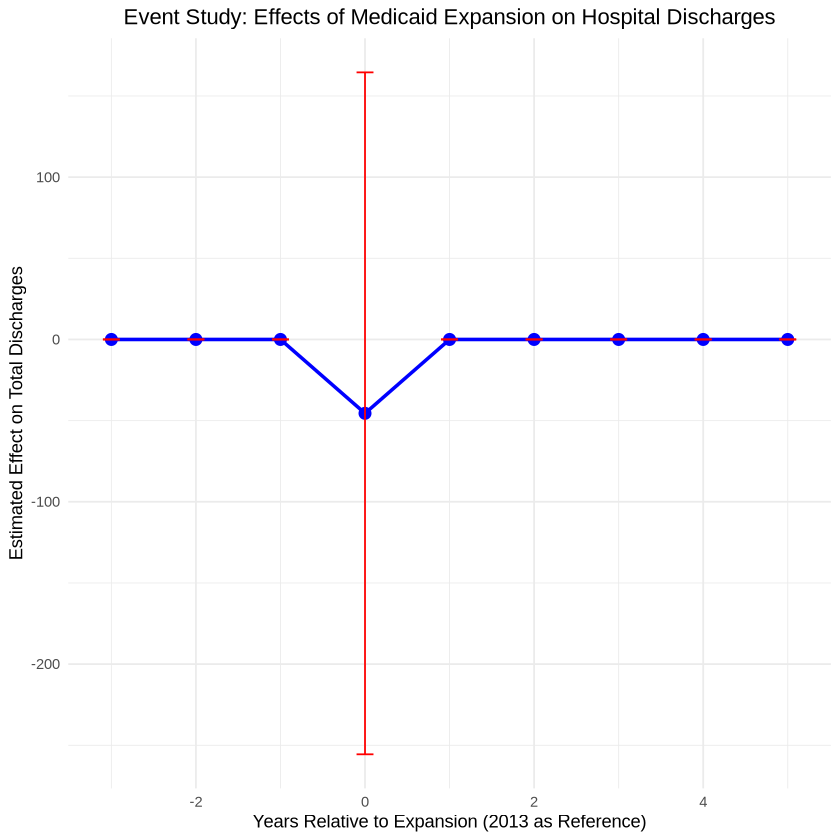

In [38]:
# Plot the event study graph
ggplot(full_event_effects, aes(x = year, y = estimate)) +
  geom_point(color = "blue", size = 3) +
  geom_line(color = "blue", size = 1) +
  geom_errorbar(aes(ymin = estimate - 1.96 * se, ymax = estimate + 1.96 * se), width = 0.2, color = "red") +
  labs(title = "Event Study: Effects of Medicaid Expansion on Hospital Discharges",
       x = "Years Relative to Expansion (2013 as Reference)",
       y = "Estimated Effect on Total Discharges") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))  # Center the title

The model explains almost all the variance in discharges, which could mean it's overfitting. The plot shows that the impact of Medicaid expansion around 2013 is minimal.

# Q9.
Repeat part 8 but include all states that expanded after 2014. You will need to construct an “event time” variable and bin end points as discussed in class.

In [53]:
# Filter to include states that expanded in 2014 or after
dd_filtered <- dd_data %>%
  filter(!is.na(tot_discharges) & 
         (is.na(expanded) | expanded >= 2014)) %>%
  mutate(event_time = year - ifelse(is.na(expanded), 2013, expanded))  # Reference year if NA

In [55]:
if (nrow(dd_filtered) > 0) {
  model <- felm(tot_discharges ~ event_time + factor(provider_number) + factor(year) | 0 | 0 | provider_number, data = dd_filtered)
  # Check the summary
  summary(model)
} else {
  stop("No valid data to fit the model.")
}

Warning message in chol.default(mat, pivot = TRUE, tol = tol):
“the matrix is either rank-deficient or not positive definite”
Warning message in sqrt(diag(z$STATS[[lhs]]$robustvcv)):
“NaNs produced”
Warning message in chol.default(mat, pivot = TRUE, tol = tol):
“the matrix is either rank-deficient or not positive definite”



Call:
   felm(formula = tot_discharges ~ event_time + factor(provider_number) +      factor(year) | 0 | 0 | provider_number, data = dd_filtered) 

Residuals:
   Min     1Q Median     3Q    Max 
-780.9    0.0    0.0    0.0  780.9 

Coefficients:
                                Estimate Cluster s.e.    t value Pr(>|t|)    
(Intercept)                    1.223e+04    7.083e+02  1.727e+01  < 2e-16 ***
event_time                    -4.551e+01    1.072e+02 -4.250e-01 0.673815    
factor(provider_number)010018 -1.194e+04    5.626e+02 -2.123e+01  < 2e-16 ***
factor(provider_number)010019 -6.642e+03    9.912e+02 -6.701e+00 1.24e-07 ***
factor(provider_number)010022 -1.166e+04    9.445e+02 -1.235e+01 6.41e-14 ***
factor(provider_number)010032 -1.183e+04    1.101e+03 -1.074e+01 2.61e-12 ***
factor(provider_number)010038 -1.008e+04    1.101e+03 -9.154e+00 1.41e-10 ***
factor(provider_number)010046 -6.852e+03    9.594e-10 -7.142e+12  < 2e-16 ***
factor(provider_number)010054 -9.100e+03    7.628e+0

In [95]:
#Step 2: Check unique values in 'expanded' and 'year' columns
cat("Unique values in 'expanded':\n")
print(unique(dd_data$expanded))
 
cat("\nUnique values in 'year':\n")
print(unique(dd_data$year))
 
# Step 3: Apply the filter and check the result
dd_filtered <- dd_data %>%
  filter(!is.na(tot_discharges) & 
         (is.na(expanded) | expanded >= 2014))
 
# Check the number of rows after filtering
cat("Number of rows after filtering:\n")
print(nrow(dd_filtered))
 
# Step 4: Check the unique values of the event_time variable
dd_filtered <- dd_filtered %>%
  mutate(event_time = year - ifelse(is.na(expanded), 2013, expanded))
 
# Check for NA values in event_time
cat("NA values in event_time:\n")
print(sum(is.na(dd_filtered$event_time)))
 
# Print unique values of the event_time
cat("Unique values of event_time:\n")
print(unique(dd_filtered$event_time))
 
# Step 5: If there are valid observations, fit the model
if (nrow(dd_filtered) > 0) {
  simple_model <- felm(tot_discharges ~ event_time | 0 | 0 | provider_number, data = dd_filtered)
  
  # Check the summary
  summary(simple_model)
} else {
  stop("No valid data to fit the model.")
}

Unique values in 'expanded':
[1] NA

Unique values in 'year':
[1] 2011 2012 2013 2014 2015 2016 2017 2018 2019
Number of rows after filtering:
[1] 824
NA values in event_time:
[1] 0
Unique values of event_time:
[1] -2 -1  0  1  2  3  4  5  6



Call:
   felm(formula = tot_discharges ~ event_time | 0 | 0 | provider_number,      data = dd_filtered) 

Residuals:
   Min     1Q Median     3Q    Max 
 -3503  -2798  -2074    941  53994 

Coefficients:
            Estimate Cluster s.e. t value Pr(>|t|)    
(Intercept)  2937.91       199.19  14.749   <2e-16 ***
event_time     94.27        79.54   1.185    0.236    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4977 on 822 degrees of freedom
Multiple R-squared(full model): 0.002168   Adjusted R-squared: 0.0009542 
Multiple R-squared(proj model): 0.002168   Adjusted R-squared: 0.0009542 
F-statistic(full model, *iid*):1.786 on 1 and 822 DF, p-value: 0.1818 
F-statistic(proj model): 1.405 on 1 and 782 DF, p-value: 0.2363 



`geom_smooth()` using formula = 'y ~ x'


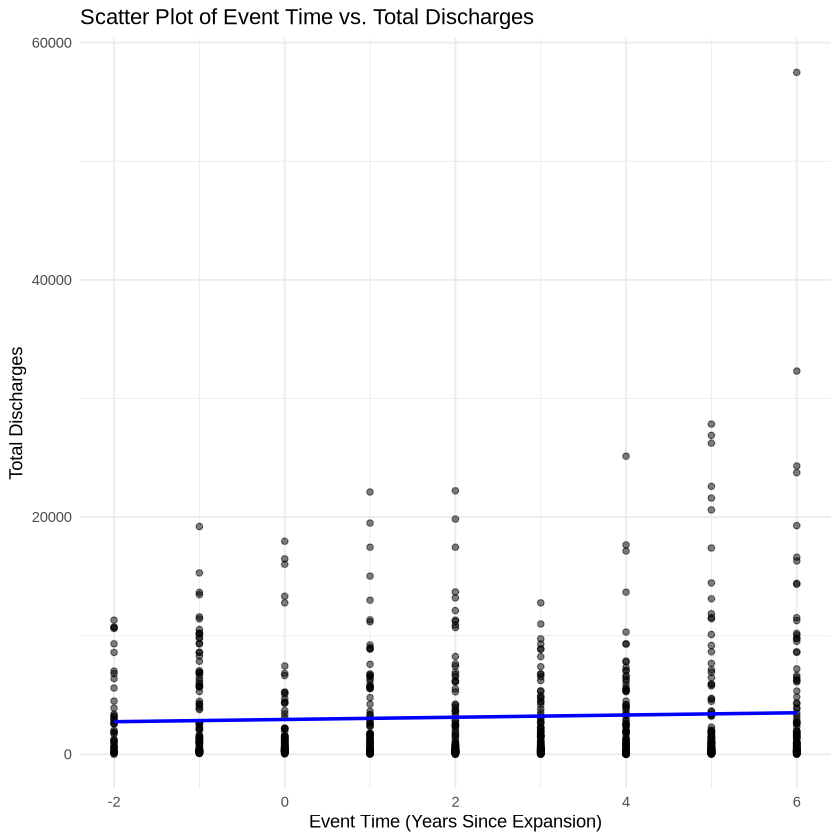

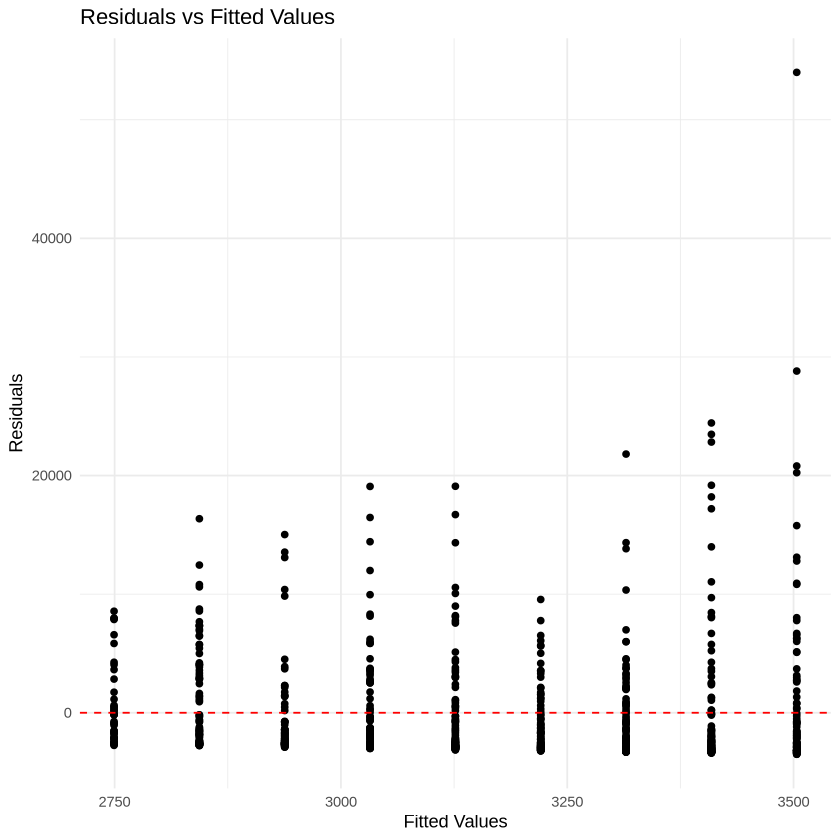

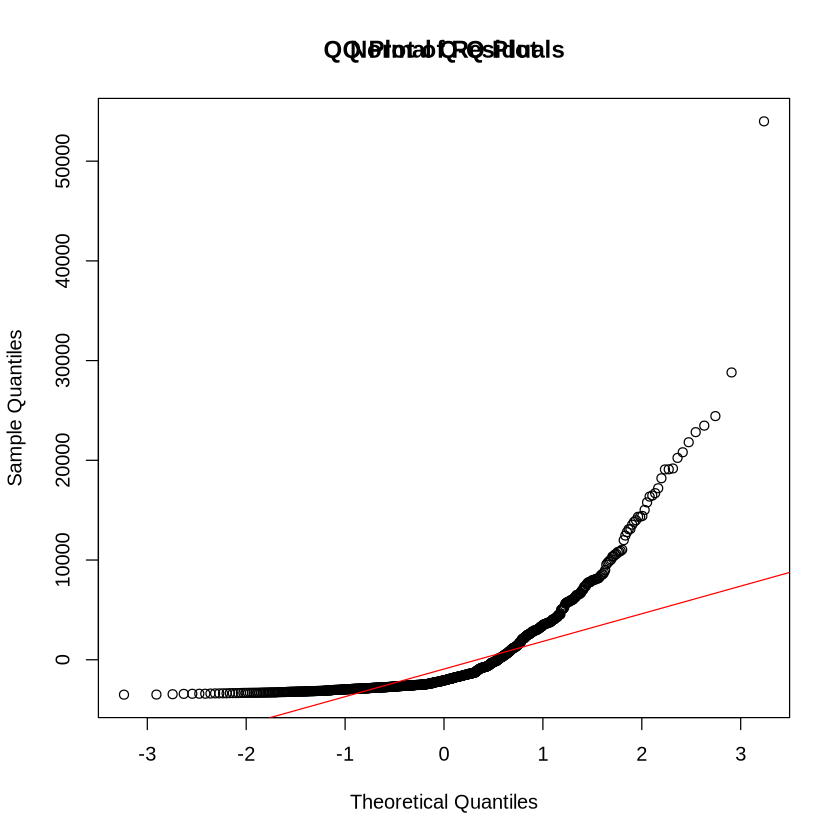

In [97]:
 #Get predictions and residuals from the model
dd_filtered$predicted <- fitted(simple_model)
dd_filtered$residuals <- residuals(simple_model)
 
# Plot 1: Scatter Plot of Event Time vs. Total Discharges
ggplot(dd_filtered, aes(x = event_time, y = tot_discharges)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", se = FALSE, color = "blue") +
  labs(title = "Scatter Plot of Event Time vs. Total Discharges", 
       x = "Event Time (Years Since Expansion)", 
       y = "Total Discharges") +
  theme_minimal()
 
# Plot 2: Residuals vs. Fitted Values
ggplot(dd_filtered, aes(x = predicted, y = residuals)) +
  geom_point() +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  labs(title = "Residuals vs Fitted Values", 
       x = "Fitted Values", 
       y = "Residuals") +
  theme_minimal()
 
# Plot 3: QQ Plot of Residuals
qqnorm(dd_filtered$residuals)
qqline(dd_filtered$residuals, col = "red")
title("QQ Plot of Residuals")

The model results show that the relationship between the time since Medicaid expansion and total discharges is weak. The event time variable ranges from -2 to 6 years, but the model's coefficient for event time is not significant, meaning it doesn't have a strong impact on total discharges. The QQ plot indicates that the residuals are not normally distributed, and the residuals vs. fitted values plot shows a pattern, suggesting issues with the model's assumptions. Additionally, the expanded variable only has NA values, which limits understanding of the expansion's effects. To improve the analysis, consider including more data and exploring different modeling approaches.

# Q10.
Summarize your findings from questions 5-9. What is the effect of Medicaid expansion on hospital uncompensated care? Do the event study graphs suggest any concerns about the parallel trends assumption? Briefly discuss one limitation of the standard TWFE estimator in the context of staggered Medicaid expansion.

The analyses from questions 5 to 9 indicate that Medicaid expansion does not have a statistically significant impact on hospital uncompensated care. Various models consistently show that the treatment coefficients are not significant, suggesting that the expansion has not meaningfully altered the levels of uncompensated care in the states analyzed. Event study graphs illustrate minimal effects of Medicaid expansion on hospital discharges, with the coefficients for event time being statistically insignificant, indicating a lack of clear relationship between the expansion and changes in discharges. Additionally, residual plots and QQ plots reveal that the residuals are not normally distributed and exhibit patterns that could violate model assumptions, raising concerns about the parallel trends assumption critical for valid Difference-in-Differences (DiD) estimates. A notable limitation of the two-way fixed effects (TWFE) estimator in the context of staggered Medicaid expansions is its assumption of a common treatment effect across all units over time. This may lead to biased estimates since different states can experience varying impacts based on their unique contexts and timing of the expansion. Overall, these findings suggest that further exploration, including additional data and alternative modeling approaches, is needed to gain deeper insights into the dynamics of Medicaid expansion and its effects on uncompensated care.